In [2]:
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from glob import glob
import os
import matplotlib.pylab as pl
from skimage import img_as_ubyte
from matplotlib.patches import Rectangle
from scipy.interpolate import griddata
from scipy.signal import argrelextrema
from scipy.ndimage import gaussian_filter, median_filter
from skimage.feature import peak_local_max
from scipy.interpolate import interp1d
import pandas as pd
from PCI_o_B import SharedFunctions as sf
from PCI_o_B import color_functions as cf
from PCI_o_B import Blob_class as BL
from PCI_o_B import Rheofluidics as RH
import time
#%matplotlib notebook
#import matplotlib as mpl
from scipy.optimize import curve_fit
import math
from skimage.measure import find_contours
import cv2 as cv
#from openpiv import tools, pyprocess, validation, filters, scaling
#from subpixel_edges import subpixel_edges
import matplotlib.cm as cm
from matplotlib.path import Path
from tqdm import tqdm
from scipy import interpolate

In [3]:
conversion_scale = .21 #mu/pixel
fps = 2000 #fps

In [4]:
path = r'D:\Rheoflu\Zeyuan\20251016_device#2_TCGP_h60_d150__channel3_MBwithBacteria_33OD\constrict_3_and_4'
imgs = cf.load_images_from_folder_parallel(path,'.tif',1,None,10)

Loading images: 100%|██████████████████████████████████████████████████████████████| 546/546 [00:04<00:00, 114.52img/s]


Loaded 546 images (skip=1, stop=None, step=10)


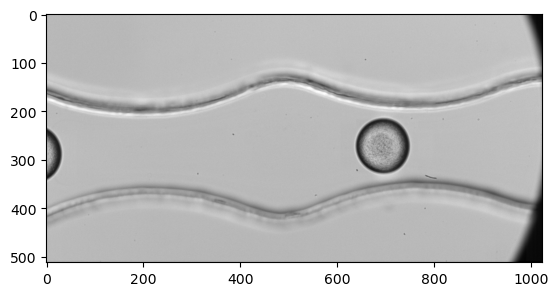

In [5]:
plt.figure()
plt.imshow(imgs[0])

In [6]:
crops, ids, xs, ys = RH.find_and_crop_droplets_in_list(
    imgs,
    x_top=629, y_top=212, w=150, h=130,
    threshold=0.6, y_shift=-15,
    save_dir=os.path.join(path, "cropped_droplets")
)

print(f"✅ Cropped {len(crops)} droplets from {len(imgs)} images")


✅ Saved coordinates CSV: D:\Rheoflu\Zeyuan\20251016_device#2_TCGP_h60_d150__channel3_MBwithBacteria_33OD\constrict_3_and_4\cropped_droplets\droplet_coordinates.csv
✅ Cropped 552 droplets from 546 images


In [7]:
sigmaCanny = 10
args_list = [(img, sigmaCanny) for img in crops]

edges = cf.run_in_parallel(
        func=RH.edge_with_Canny,
        args_list=args_list,
        desc="Finding Edges with Canny",
        unit="img"
    )

x, y = zip(*edges)
xEdges = np.array(y, dtype=object)  # keeps inner arrays/lists as objects
yEdges = np.array(x, dtype=object)

x_cm = np.asarray([np.mean(x) for x in xEdges])
y_cm = np.asarray([np.mean(y) for y in yEdges])

Finding Edges with Canny: 100%|████████████████████████████████████████████████████| 552/552 [00:03<00:00, 158.19img/s]


In [9]:
xEdges_out = []
yEdges_out = []

for i in range(len(xEdges)):  # loop over frames
    x = xEdges[i]
    y = yEdges[i]

    # Compute center for this frame
    x_center = np.mean(x)
    y_center = np.mean(y)

    # Compute radius for each point
    r = np.sqrt((x - x_center)**2 + (y - y_center)**2)

    # Keep only outer circle (points with radius near the max)
    mask = r >= 0.9 * np.max(r)

    # Store filtered points
    xEdges_out.append(x[mask])
    yEdges_out.append(y[mask])

# Replace the old arrays with the filtered ones
xEdges = xEdges_out
yEdges = yEdges_out

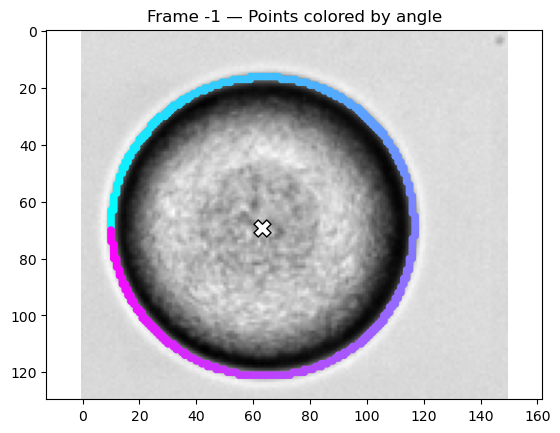

In [13]:
index =-1

plt.figure()
plt.imshow(crops[index], cmap='gray')

# compute angles for this frame
x = xEdges[index]
y = yEdges[index]
x_center = x_cm[index]
y_center = y_cm[index]

# angle of each point relative to center
theta = np.arctan2(y - y_center, x - x_center)

# sort by angle if you want smooth coloring around circle (optional)
# sort_idx = np.argsort(theta)
# x, y, theta = x[sort_idx], y[sort_idx], theta[sort_idx]

# scatter colored by angle
plt.scatter(x, y, c=theta, cmap='cool', s=20)

# plot center
plt.scatter(x_center, y_center, marker='X', s=150, c='white', edgecolor='black')


plt.title(f'Frame {index} — Points colored by angle')
plt.axis('equal')
plt.show()

In [14]:
OrderExpasnion  = 4
args_list = [(x,y, OrderExpasnion) for x,y in zip(xEdges,yEdges)]

FitResults = cf.run_in_parallel(
        func=RH.fit_Fourier_cos_only,
        args_list=args_list,
        desc="Fitting edges",
        unit="img"
    )

Fitting edges: 100%|███████████████████████████████████████████████████████████████| 552/552 [00:03<00:00, 161.96img/s]


In [15]:
AlphaParams, AlphaParamsCov,theta_fit,r_fit,theta,r = zip(*FitResults)

Alphas = np.array(AlphaParams, dtype=object)  # keeps inner arrays/lists as objects
AlphasCov = np.array(AlphaParamsCov, dtype=object)
thetas_fit   = np.array(theta_fit, dtype=object)
r_fit   = np.array(r_fit, dtype=object)
thetas   = np.array(theta, dtype=object)
r   = np.array(r, dtype=object)

a_0,a_1,a_2,a_3,a_4 = zip(*Alphas)

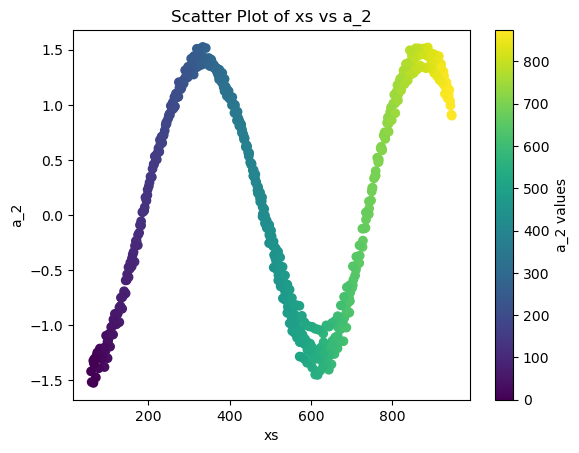

In [16]:
plt.figure()
ax = plt.axes()

# Assuming xs and a_2 are defined arrays/lists of same length
scatter = plt.scatter(xs+x_cm, a_2, marker='o', c=xs, cmap='viridis')  # colors mapped to a_2 values
plt.colorbar(scatter, label='a_2 values')  # optional: adds a colorbar

plt.xlabel('xs')
plt.ylabel('a_2')
plt.title('Scatter Plot of xs vs a_2')

plt.show()

In [17]:
df = pd.read_csv(r'D:\Rheoflu\Zeyuan\20251016_device#2_TCGP_h60_d150__channel3_MBwithBacteria_33OD\constrict_3_and_4\cropped_droplets\droplet_coordinates.csv')

# Compute velocities (e.g., 0.5 µm per pixel, 1000 fps)
velocity_dx = RH.compute_dx(df)


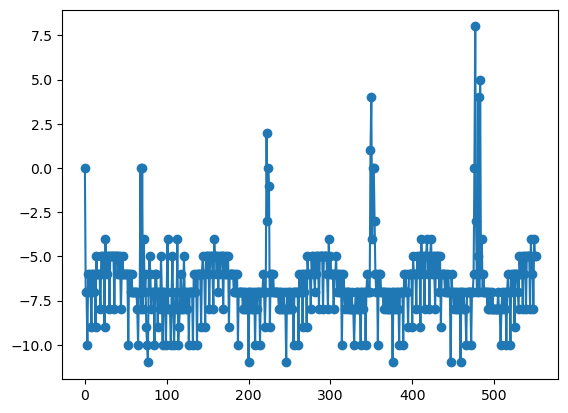

In [18]:
plt.figure()

plt.plot(velocity_dx,marker='o')

In [19]:
sorted_indices = np.argsort(xs)

# Reorder x and y
x_sorted = np.asarray(xs)[sorted_indices]
a_2_sorted = np.asarray(a_2)[sorted_indices]
a_0_sorted = np.asarray(a_0)[sorted_indices]
x_cm_sorted = np.asarray(x_cm)[sorted_indices]

In [20]:
path = r"D:\Rheoflu\Zeyuan\20251016_device#2_TCGP_h60_d150__channel3_MBwithBacteria_33OD\constrict_3_and_4\edges.csv"
x,dist = RH.determine_distances(path)

df = pd.read_csv(r'D:\Rheoflu\Zeyuan\20251016_device#2_TCGP_h60_d150__channel3_MBwithBacteria_33OD\constrict_3_and_4\cropped_droplets\droplet_coordinates.csv')

# Compute velocities (e.g., 0.5 µm per pixel, 1000 fps)
velocity_dx = RH.compute_dx(df)

interp_dist = interp1d(x,dist)

# 1. Build an interpolating function for stress
dist_fun = interp1d(x_sorted, interp_dist(x_sorted), bounds_error=False, fill_value="extrapolate")

# 2. Evaluate stress at shifted positions (same as a_2)
flow = dist_fun(x_sorted + x_cm_sorted) * 60 * velocity_dx * conversion_scale**2 * fps

mean_flow = np.nanmean(flow) # this flow is in mum^3/s

print(np.nanmean(flow)*1e-9)

0.007498807719789567


C:\Users\mateo\anaconda3\envs\DLSenv\Lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


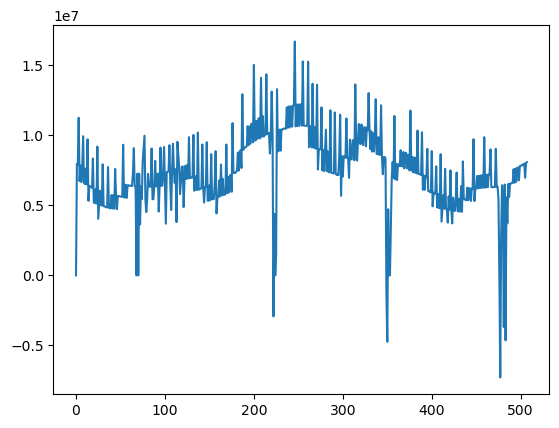

In [21]:
plt.figure()
plt.plot(flow)

In [22]:
viscosity = .02 #Pa/s

dist_micron = dist*conversion_scale

x_str, stress = RH.calc_stress_middle_channel(x,dist_micron,mean_flow,viscosity )
x_fit, stress_fit, params, r2 = RH.fit_sine(x_str, stress,n_points=len(a_2),plot=False)

interp_stress = interp1d(x_fit, stress_fit)

# 1. Build an interpolating function for stress
stress_fun = interp1d(x_sorted, interp_stress(x_sorted), bounds_error=False, fill_value="extrapolate")

# 2. Evaluate stress at shifted positions (same as a_2)
stress_shifted = stress_fun(x_sorted + x_cm_sorted)


In [42]:
omega_space = (params[1]/conversion_scale)
vel = np.mean(-velocity_dx) * conversion_scale * fps

omega = vel * omega_space

print(omega_space)
print(omega)

0.008460697875655338
23.529016863982804


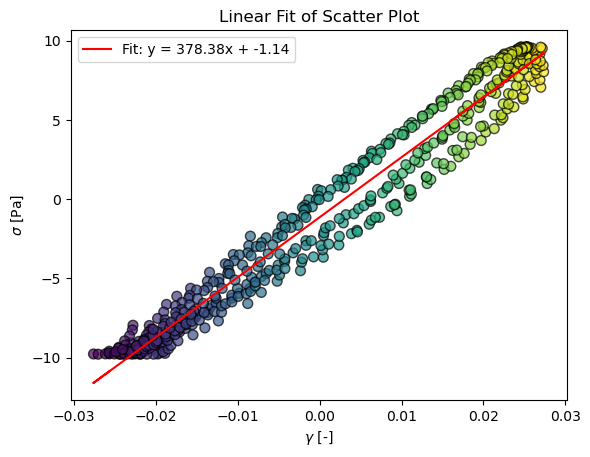

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
x = a_2_sorted/a_0_sorted
y = -stress_shifted*1e-6


# Remove NaN and Inf values
mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask]
y_clean = y[mask]

# Check if enough unique x-values exist
if len(np.unique(x_clean)) < 2:
    raise ValueError("Not enough unique x-values to perform a linear fit.")

# Perform fit safely
m, b = np.polyfit(x_clean, y_clean, 1)
y_fit = m * x + b
# Plot
plt.figure()
plt.scatter(x, y, marker='o', c=a_2_sorted, cmap='viridis',edgecolor='k',s=50,alpha=.7)
plt.plot(x, y_fit, color='red', label=f'Fit: y = {m:.2f}x + {b:.2f}')
plt.xlabel(r'$\gamma$ [-]')
plt.ylabel(r'$\sigma$ [Pa]')
plt.legend()
plt.title('Linear Fit of Scatter Plot')
plt.show()


In [24]:
average_radius = np.mean(a_0)*conversion_scale*1e-6
print(average_radius)

1.1539309959784072e-05


In [25]:
Gamma = m * average_radius

print(r'surface tension = '+str(np.round(Gamma*1e3,2))+' mN/m')

surface tension = 4.37 mN/m


In [34]:
L_channel = 1024
time_max = L_channel / np.mean(-velocity_dx)  / fps 
time = np.linspace(0,time_max,len(a_2_sorted/a_0_sorted))*1000

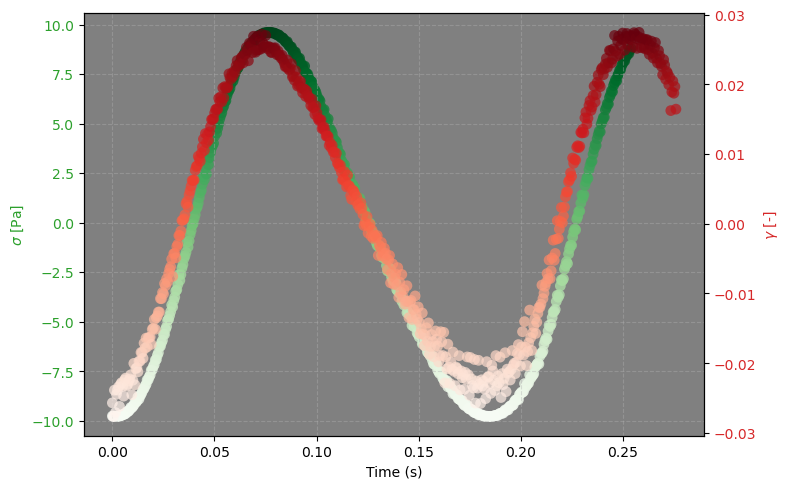

In [32]:
import numpy as np
import matplotlib.pyplot as plt



# Create figure
fig, ax = plt.subplots(figsize=(8, 5))
ax1 = ax.twinx()

# Main scatter (y vs time)
sc1 = ax.scatter(time, y, c=y, cmap='Greens', s=60, alpha=0.8, edgecolor='none')
ax.set_xlabel("Time (s)")
ax.set_ylabel("$\sigma$ [Pa]", color='tab:green')
ax.tick_params(axis='y', labelcolor='tab:green')


# Secondary scatter (x vs time, red color scale)
sc2 = ax1.scatter(time, x, c=x, cmap='Reds', s=60, alpha=0.7, edgecolor='none')
ax1.set_ylabel("$\gamma$ [-]", color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')



# Style tweaks

ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()

ax.set_facecolor('gray')


In [43]:
omega_space = (params[1]/conversion_scale)
vel = np.mean(-velocity_dx) * conversion_scale * fps

omega = 2*np.pi*vel * omega_space

print(omega_space)
print(omega)

n = len(x_fit)  # example length
omega_arr = np.full(n, omega)

0.008460697875655338
147.83717305215745


In [45]:
# Path to the output file
path = r'D:\Rheoflu\Zeyuan\20251016_device#2_TCGP_h60_d150__channel3_MBwithBacteria_33OD\processed\stress_stran_constrict_3_4.txt'

combined_array = np.column_stack((time,x_fit*conversion_scale, x, y, np.asarray(a_0)*conversion_scale,omega_arr))

# --- Create parent folder if it doesn't exist ---
os.makedirs(os.path.dirname(path), exist_ok=True)

# --- Save data to file ---
np.savetxt(path, combined_array, header='time [s] pos[mu] strain [-] stress [pa] a0 [mum] omega [rad\s]')